In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm  import tqdm
import json
import ast
import numpy as np
import gemmi
from mlindex.dataset_generation.EntryHelpers import spacegroup_to_symmetry 
from mlindex.utilities.Reindexing import reindex_entry_monoclinic
from mlindex.utilities.Reindexing import reindex_entry_orthorhombic
from mlindex.utilities.Reindexing import reindex_entry_triclinic
from mlindex.utilities.Reindexing import hexagonal_to_rhombohedral_unit_cell
import sklearn.linear_model
import sklearn.preprocessing

from parse_opxrd import pick_peaks
from parse_opxrd import get_symmetry
from parse_opxrd import get_q_lattice

In [2]:
root = '/global/cfs/cdirs/m4064/dwmoreau/opxrd'

In [4]:
def parse_file(file_name):
    df = pd.read_json(file_name)
    data = json.loads(df['label'][0])
    phases = data['phases']
    if len(phases) > 0:
        phase = json.loads(data['phases'][0])
        spacegroup_number = phase['spacegroup']
        if spacegroup_number:
            spacegroup = gemmi.SpaceGroup(spacegroup_number).hm
        else:
            spacegroup = None
        unit_cell_entry = np.array(ast.literal_eval(phase['lattice']))
        unit_cell_entry[3:] *= np.pi/180
    else:
        spacegroup_number = None
        spacegroup = None
        unit_cell_entry = None
        unit_cell = None
    xray_info = json.loads(data.get("xray_info") or "{}")

    if spacegroup is None and unit_cell_entry is None:
        crystal_system = None
        bravais_lattice = None
        lattice_system = None
    elif spacegroup is None:
        unit_cell, crystal_system = get_symmetry(unit_cell_entry)
        crystal_system = crystal_system.lower()
        lattice_system = crystal_system
        if crystal_system == 'triclinic':
            bravais_lattice = 'aP'
        elif crystal_system == 'monoclinic':
            bravais_lattice = 'mP'
        elif crystal_system == 'orthorhombic':
            bravais_lattice = 'oP'
        elif crystal_system == 'tetragonal':
            bravais_lattice = 'tP'
        elif crystal_system == 'cubic':
            bravais_lattice = 'cP'
        elif crystal_system == 'hexagonal':
            bravais_lattice = 'hP'
        elif crystal_system == 'rhombohedral':
            bravais_lattice = 'hR'
        else:
            assert False
    else:
        bravais_lattice, crystal_family, crystal_system, lattice_system = spacegroup_to_symmetry(int(spacegroup_number))
        if lattice_system == 'triclinic':
            bravais_lattice = 'aP'
            unit_cell, _ = reindex_entry_triclinic(unit_cell_entry, space='direct')
        elif lattice_system == 'monoclinic':
            unit_cell = np.array(unit_cell_entry)
            unit_cell, spacegroup, _ = reindex_entry_monoclinic(
                np.array(unit_cell),
                spacegroup,
                space='direct'
            )
        elif lattice_system == 'orthorhombic':
            spacegroup, _, unit_cell, _ = reindex_entry_orthorhombic(
                np.array(unit_cell_entry),
                spacegroup,
                int(spacegroup_number)
                )
        elif lattice_system == 'rhombohedral':
            if np.all(np.isclose(unit_cell_entry[3:], [np.pi/2, np.pi/2, 2*np.pi/3])):
                unit_cell, _ = hexagonal_to_rhombohedral_unit_cell(unit_cell_entry)
            else:
                unit_cell = unit_cell_entry
            print(unit_cell)
        else:
            unit_cell = unit_cell_entry
    info =  {
        "file_name": file_name,
        "primary_wavelength": float(xray_info["primary_wavelength"]) if xray_info.get("primary_wavelength") else None,
        "secondary_wavelength": float(xray_info["secondary_wavelength"]) if xray_info.get("secondary_wavelength") else None,
        "spacegroup": spacegroup,
        "unit_cell": unit_cell,
        "unit_cell_entry": unit_cell_entry,
        "theta2": df['two_theta_values'],
        "I": df['intensities'],
        "q": None,
    }
    valid = info["I"] > 0
    info["I"] = np.array(info["I"][valid])
    info["theta2"] = np.array(info["theta2"][valid])
    if info['primary_wavelength']:
        info['q'] = 2 * np.sin(np.pi/180 * info['theta2']/2) / info['primary_wavelength']

    info['bravais_lattice'] = bravais_lattice
    info['lattice_system'] = lattice_system
    return info

def plot(info, q_found=None, q_lattice=None):
    fig, axes = plt.subplots(1, 1, figsize=(15, 4))
    axes.plot(info['q'], info['I'])
    ylims = axes.get_ylim()
    if not q_found is None and len(q_found) > 0:
        for q in q_found:
            axes.plot([q, q], ylims, color=[0, 0, 0])
        axes.set_xlim([axes.get_xlim()[0], q_found[-1]])
    if not q_lattice is None:
        for q in q_lattice:
            axes.plot([q, q], [ylims[0], 0.5*ylims[1]], color=[1, 0, 0])
    axes.set_ylim(ylims)
    plt.show()

#source = 'INT'
#snr_threshold=10
#min_relative_height=0.03

source = 'CNRS'
snr_threshold=6
min_relative_height=0.015

file_names = [] 
for file_name in sorted(os.listdir(root + '/' + source)):
    check0 = file_name.endswith('.json')
    check1 = file_name.endswith('opt.json')
    if check0 and not check1:
        file_names.append(file_name)

output_data = []
all_lattices = []
for file_name in tqdm(file_names):
    if file_name.endswith('.json'):
        info = parse_file(root + '/' + source + '/' + file_name)
        #print(root + '/' + source + '/' + file_name)
        #print(info['primary_wavelength'], info['secondary_wavelength'])
        #print(info['unit_cell'], info['spacegroup'])
        #print()
        all_lattices.append([info['unit_cell_entry'], info['unit_cell']])
        if not info['q'] is None:
            try:
                peaks, bg, diag = pick_peaks(
                    info['q'], info['I'],
                    snr_threshold=snr_threshold,
                    min_relative_height=min_relative_height,
                    profile="pseudo_voigt",
                    bg_width=None,
                    bg_iterations=20,
                    smooth_window=10,  
                    merge_distance_factor=4,
                    show_diagnostics=False,
                )
                q_found = np.array([p['center'] for p in peaks])
                sigma_found = np.array([p['sigma'] for p in peaks])
                q_lattice = None
                if not info['unit_cell'] is None:
                    try:
                        q_lattice = get_q_lattice(info)
                    except:
                        pass
                if len(q_found) >= 20:
                    info['peak_positions'] = q_found
                    info['peak_sigmas'] = sigma_found
                    info['file_name'] = root + '/' + source + '/' + file_name
                    output_data.append(info)
                    #plot(info, q_found, q_lattice)  
                    #plot(info)
            except:
                continue
                #print('FAIL')
np.save(f'{source}_lattices.npy', np.array(all_lattices))
output_data = pd.DataFrame(output_data)
output_data.to_json(f'{source}_output_data.json')

  4%|▎         | 37/1052 [00:37<06:39,  2.54it/s]

[9.11343711 9.11343711 9.11343711 1.04704968 1.04704968 1.04704968]


  6%|▌         | 62/1052 [00:47<09:18,  1.77it/s]

[7.40030177 7.40030177 7.40030177 0.47569235 0.47569235 0.47569235]


 10%|▉         | 101/1052 [01:35<17:24,  1.10s/it] 

...

 95%|█████████▌| 1000/1052 [22:48<00:57,  1.10s/it]

[7.343719   7.343719   7.343719   0.47545037 0.47545037 0.47545037]


 96%|█████████▌| 1010/1052 [22:54<00:32,  1.29it/s]

[8.06150808 8.06150808 8.06150808 0.53535608 0.53535608 0.53535608]


100%|██████████| 1052/1052 [23:48<00:00,  1.36s/it]


In [ ]:
np.save(f'{source}_lattices.npy', np.array(all_lattices))
output_data = pd.DataFrame(output_data)
output_data.to_json(f'{source}_output_data.json')

In [3]:
output_data = pd.read_json(f'INT_output_data_all.json')
#output_data = pd.read_json(f'CNRS_output_data_verified_final.json').T
#output_data = pd.read_json(f'CNRS_output_data.json')


In [6]:
coeffs_q = []
coeffs_q_sk = []
max_q = 1
max_s = 0.003
for index in range(len(output_data)):
    entry = output_data.iloc[index]
    q = np.array(entry.peak_positions)
    s = np.array(entry.peak_sigmas)
    if len(q) == len(s):
        valid = (q < max_q) & (s < max_s)
        if np.sum(valid) >= 5:
            q = q[valid]
            s = s[valid]
            coeffs_q.append(np.polyfit(q, s, 1))
            model = sklearn.linear_model.HuberRegressor()
            model.fit(q[:, np.newaxis], s)
            coeffs_q_sk.append([model.coef_[0], model.intercept_])
    
coeffs_q = np.stack(coeffs_q, axis=0)
coeffs_q_sk = np.stack(coeffs_q_sk, axis=0)
q_peak = []
sigma_peak = []
for index in range(len(output_data.peak_positions)):
    q = np.array(output_data.peak_positions[index])
    s = np.array(output_data.peak_sigmas[index])
    valid = (q < max_q) & (s < max_s)
    q = q[valid]
    s = s[valid]
    if len(q) == len(s):
        q_peak.append(q)
        sigma_peak.append(s)
q_peak = np.concatenate(q_peak)
sigma_peak = np.concatenate(sigma_peak)


[0.00091629 0.00072894]


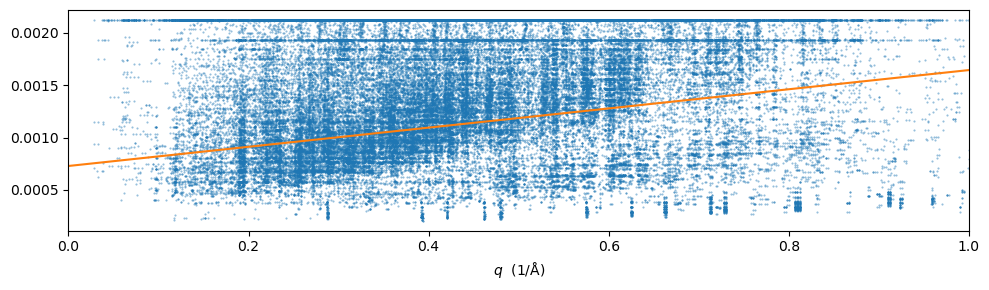

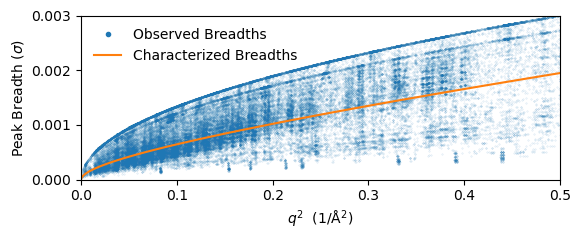

In [22]:
p_q = np.median(coeffs_q, axis=0)
p_q_sk = np.median(coeffs_q_sk, axis=0)

#print(p_q)
print(p_q_sk)
x_fit = np.linspace(0, max_q, 100)
y_fit = np.polyval(p_q_sk, x_fit)

fig, axes = plt.subplots(1, 1, figsize=(10, 3))
axes.plot(q_peak, sigma_peak, marker='.', linestyle='none', markersize=1, alpha=0.5)
axes.plot(x_fit, y_fit)
#axes.set_yscale('log')
#axes.set_ylim([0, 0.001])
axes.set_xlim([0, max_q])
axes.set_xlabel(r'$q$  $(1/\mathrm{\AA})$')
#axes.set_ylabel('
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(6, 2.5))
axes.plot(
    q_peak**2, 2*q_peak*sigma_peak,
    marker='.', linestyle='none', markersize=0.5, alpha=0.25,
    label='Observed Breadths',
)
axes.plot(x_fit**2, 2*x_fit*y_fit, label='Characterized Breadths')
#axes.plot(x_fit**2, 0.00034 + 0.0042*x_fit**2)
#axes.set_yscale('log')
#axes.set_ylim([0, 0.001])
axes.set_xlim([0, 0.5])
axes.set_xlabel(r'$q^2$  $(1/\mathrm{\AA}^2)$')
axes.set_ylim([0, 0.003])
axes.set_ylabel(r'Peak Breadth ($\sigma$)')
legend = axes.legend(frameon=False)
legend.legend_handles[0].set_markersize(6)
legend.legend_handles[0].set_alpha(1.0)
fig.tight_layout()
fig.savefig('INT_peak_breadths.png', dpi=200)
plt.show()

In [ ]:
# [0.00089747 0.00078896]